In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configurable paths

# Promoter-level chec-seq binding signal for Human TFs
sumprom_chec_glob = "sumproms/*gz"

## Imports

In [3]:
import numpy as np
import pandas as pd

import glob
from scipy.stats import zscore

import matplotlib.pyplot as plt

## Load data

In [4]:
sumprom_chec_files = glob.glob(sumprom_chec_glob)
sumprom_all = pd.concat([pd.read_parquet(x) for x in sumprom_chec_files], axis=1)

corr_cutoff = 0.895

def filter_reproducible(sumprom_all: pd.DataFrame, cutoff) -> pd.DataFrame:
    df = sumprom_all.copy()
    groups = pd.Series(df.columns, index=df.columns).str.rsplit("_", n=2).str[0]
    
    keep = []
    for _, members in groups.groupby(groups).groups.items():
        if len(members) < 2:
            continue
        corr = df[members].corr()
        np.fill_diagonal(corr.values, np.nan)
        max_corrs = corr.max(axis=1)
        reproducible = max_corrs[max_corrs >= cutoff].index.tolist()
        keep.extend(reproducible)
    return df[keep]

sumprom_filtered = filter_reproducible(sumprom_all, cutoff=corr_cutoff)
sumprom_filtered["FOXL2_2_S153"] = sumprom_all["FOXL2_2_S153"]
sumprom_filtered["FOXL2_3_S154"] = sumprom_all["FOXL2_3_S154"]
cols = sumprom_filtered.columns.astype(str)
base_sumprom = cols.str.rsplit('_', n=2).str[0]
sumprom = sumprom_filtered.T.groupby(base_sumprom).mean().T
sumprom_z=sumprom.apply(zscore)

In [5]:
dbd_idr_dict = {

    "ELF1_DBD_ERF_dict": {
    "ELF1_DBD_ERF": ["ELF1", "ERF1"],
    "ELF1": ["ELF1", "ERF1"],
    "ERF1": ["ELF1", "ERF1"]},

    "ERG_DBD_ERF_dict": {
    "ERG_DBD_ERF": ["ERG", "ERF1"],
    "ERG": ["ERG", "ERF1"],
    "ERF1": ["ERG", "ERF1"]},

    "ERG_DBD_ELF1_dict": {
    "ERG_DBD_ELF1": ["ERG", "ELF1"],
    "ERG": ["ERG", "ELF1"],
    "ELF1": ["ERG", "ELF1"]},

    "ERG_DBD_ELF2_dict": {
    "ERG_DBD_ELF2": ["ERG", "ELF2"],
    "ERG": ["ERG", "ELF2"],
    "ELF2": ["ERG", "ELF2"]},
    
    "ERG_DBD_ELK1_dict": {
    "ERG_DBD_ELK1": ["ERG", "ELK1"],
    "ERG": ["ERG", "ELK1"],
    "ELK1": ["ERG", "ELK1"]},

    "ERG_DBD_FLI1_dict": {
    "ERG_DBD_FLI1": ["ERG", "FLI1"],
    "ERG": ["ERG", "FLI1"],
    "FLI1": ["ERG", "FLI1"]},

    "FOXL2_DBD_FOXP1_IDR_dict": {
    "FOXL2_DBD_FOXP1_IDR": ["FOXL2", "FOXP1"],
    "FOXL2": ["FOXL2", "FOXP1"],
    "FOXP1": ["FOXL2", "FOXP1"]},

    "FOXL2_DBD_FOXP2_IDR_dict": {
    "FOXL2_DBD_FOXP2_IDR": ["FOXL2", "FOXP2"],
    "FOXL2": ["FOXL2", "FOXP2"],
    "FOXP2": ["FOXL2", "FOXP2"]},
}

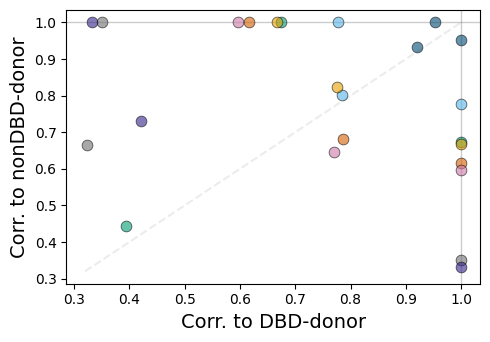

In [6]:
# Build a table of correlation values for each group
rows = []
for group, sub in dbd_idr_dict.items():
    # Use the first label in the group (same for all entries)
    lab = next(iter(sub.keys()))
    
    for anchor, (x_s, y_s) in sub.items():
        # Compute correlation of the anchor sample with two comparison samples
        rows.append({
            "group": group,
            "label": lab,
            "x": sumprom_z[anchor].corr(sumprom_z[x_s]),  # correlation to DBD-donor
            "y": sumprom_z[anchor].corr(sumprom_z[y_s])   # correlation to nonDBD-donor
        })

# Convert collected data into a DataFrame
pts = pd.DataFrame(rows)


# Compute a representative correlation per group to determine plotting order
# Uses the first (x, y) pair in each group
pair_corr = {
    g: sumprom_z[next(iter(sub.values()))[0]].corr(
        sumprom_z[next(iter(sub.values()))[1]]
    )
    for g, sub in dbd_idr_dict.items()
}

# Sort groups from highest to lowest correlation
ordered_groups = sorted(pair_corr, key=lambda g: pair_corr[g], reverse=True)


# Define colors for groups (highest correlation = blue, lowest = purple)
palette = ["#004A75", "#56B4E9", "#009E73", "#E69F00",
           "#D55E00", "#CC79A7", "#6F6F6F", "#332288"]

group_colors = dict(zip(ordered_groups, palette))


# Create readable labels for the legend
group_label = {}
for g in ordered_groups:
    # Take first label from the group and format it
    base = "_".join(pts.loc[pts.group.eq(g), "label"].iloc[0].split("_")[:3])
    base = f"{base}_nonDBD"

    # Split into two lines for better readability in legend
    toks = base.split("_")
    group_label[g] = "-".join(toks[:2]) + "\n" + "-".join(toks[2:])


# Create scatter plot
fig, ax = plt.subplots(figsize=(5, 4))

# Add a faint diagonal reference line (y = x)
ax.plot([0.32, 1], [0.32, 1], "--", color="grey", alpha=0.15, zorder=0)

# Plot each group as a separate set of points
for g in ordered_groups:
    gdf = pts[pts.group.eq(g)]
    ax.scatter(
        gdf.x,
        gdf.y,
        s=60,
        alpha=0.6,
        color=group_colors[g],
        label=group_label[g],
        edgecolor="black",
        linewidths=0.6
    )

# Label axes
ax.set_xlabel("Corr. to DBD-donor", fontsize=14)
ax.set_ylabel("Corr. to nonDBD-donor", fontsize=14)

# Add reference lines at correlation = 1
ax.axhline(1, linewidth=1, color="black", alpha=0.2, zorder=0)
ax.axvline(1, linewidth=1, color="black", alpha=0.2, zorder=0)


# # Uncomment this section to display the legend
# # Legend is ordered by group strength (highest correlation first)
# handles, labels = ax.get_legend_handles_labels()
# order = [labels.index(group_label[g]) for g in ordered_groups]
# leg = fig.legend(
#     [handles[i] for i in order],
#     [labels[i] for i in order],
#     loc="lower center",
#     bbox_to_anchor=(0.5, -0.02),
#     ncol=8,
#     frameon=False,
#     columnspacing=0.6,
#     markerscale=1.2,
#     handletextpad=0
# )

# Adjust layout to leave space for the legend
plt.tight_layout(rect=[0, 0.12, 1, 1])

plt.show()

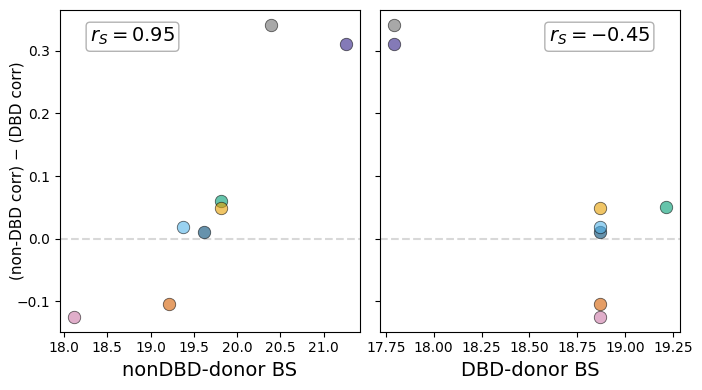

In [7]:
# Ensure both dataframes have identical rows and columns in the same order
sumprom_z, sumprom = sumprom_z.align(sumprom, join="inner", axis=0)
sumprom_z, sumprom = sumprom_z.align(sumprom, join="inner", axis=1)


# Compute binding strength for a sample
# Defined as log2 of the total signal at positions where z-score > 3
def binding_strength(sample):
    m = sumprom_z[sample] > 3
    return np.log2(sumprom.loc[m, sample].sum())


# Create a consistent group ordering based on correlation between DBD and nonDBD samples
pair_corr = {
    g: sumprom_z[v[0]].corr(sumprom_z[v[1]])
    for g, sub in dbd_idr_dict.items()
    for v in [next(iter(sub.values()))]
}

# Sort groups from highest to lowest correlation
ordered_groups = sorted(pair_corr, key=lambda g: pair_corr[g], reverse=True)

# Assign a fixed color to each group based on this order
palette = ["#004A75", "#56B4E9", "#009E73", "#E69F00",
           "#D55E00", "#CC79A7", "#6F6F6F", "#332288"]

group_colors = dict(zip(ordered_groups, palette))


# Build a dataframe with one point per group
# x-values: binding strength of DBD and nonDBD donors
# y-value: difference in correlation (nonDBD - DBD)
rows = []
for g, sub in dbd_idr_dict.items():
    anchor = next(iter(sub.keys()))        # e.g. "ERG_DBD_ELF2"
    dbd, nondbd = next(iter(sub.values()))  # e.g. ["ERG", "ELF2"]

    # Compute difference in correlation to the anchor
    y = sumprom_z[anchor].corr(sumprom_z[nondbd]) - sumprom_z[anchor].corr(sumprom_z[dbd])

    rows.append({
        "group": g,
        "label": "_".join(anchor.split("_")[:3]),
        "x_dbd": binding_strength(dbd),
        "x_nondbd": binding_strength(nondbd),
        "y": y
    })

df = pd.DataFrame(rows)


# Create two side-by-side scatter plots sharing the same y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 4), sharey=True)

# Small vertical offset to avoid overlap for a specific point
y_jitter = 0.01
jitter_label = "ELF1_DBD_ERF"

# Plot each group as a single point in both subplots
for g in ordered_groups:
    d = df[df.group.eq(g)].iloc[0]

    # Apply jitter only to a specific label in the nonDBD plot
    y1 = d["y"] + (y_jitter if d["label"] == jitter_label else 0.0)

    # Left plot: nonDBD binding strength vs correlation difference
    ax1.scatter(
        d["x_nondbd"], y1,
        s=80, alpha=0.6,
        color=group_colors[g],
        edgecolor="black", linewidths=0.6,
        label=d["label"]
    )

    # Right plot: DBD binding strength vs correlation difference
    ax2.scatter(
        d["x_dbd"], d["y"],
        s=80, alpha=0.6,
        color=group_colors[g],
        edgecolor="black", linewidths=0.6,
        label=d["label"]
    )


# Add horizontal reference line at y = 0
for ax in (ax1, ax2):
    ax.axhline(0, linestyle="--", color="grey", alpha=0.3, zorder=0)
    ax.grid(False)


# Set axis labels
ax1.set_xlabel("nonDBD-donor BS", fontsize=14)
ax2.set_xlabel("DBD-donor BS", fontsize=14)
ax1.set_ylabel("(non-DBD corr) − (DBD corr)", fontsize=11, labelpad=-6)


# Compute Pearson and Spearman correlations between x and y
r1 = df["x_nondbd"].corr(df["y"], method="pearson")
r2 = df["x_dbd"].corr(df["y"], method="pearson")
rs1 = df["x_nondbd"].corr(df["y"], method="spearman")
rs2 = df["x_dbd"].corr(df["y"], method="spearman")

# Display Spearman correlation values on each subplot
ax1.text(
    0.1, 0.95,
    rf"$r_{{S}} = {rs1:.2f}$",
    transform=ax1.transAxes,
    fontsize=14,
    ha="left", va="top",
    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="black", alpha=0.3)
)

ax2.text(
    0.9, 0.95,
    rf"$r_{{S}} = {rs2:.2f}$",
    transform=ax2.transAxes,
    fontsize=14,
    ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="black", alpha=0.3)
)

plt.tight_layout()
plt.show()